In [22]:
### Pipelines

# Nulls - Impute with mean/ mode
mean - LotFrontage, GarageYrBlt, MasVnrArea
TrainDF_HousingData['LotFrontage'] = TrainDF_HousingData['LotFrontage'].fillna(TrainDF_HousingData['LotFrontage'].mean())
TrainDF_HousingData['GarageYrBlt'] = TrainDF_HousingData['GarageYrBlt'].fillna(TrainDF_HousingData['GarageYrBlt'].mean())
TrainDF_HousingData['MasVnrArea'] = TrainDF_HousingData['MasVnrArea'].fillna(TrainDF_HousingData['MasVnrArea'].mean())

mode - BsmtCond, BsmtQual, FireplaceQu (Impute or ignore feature as 40% are nulls?), GarageType, GarageFinish, GarageQual, GarageCond, 
BsmtExposure,BsmtFinType1, BsmtFinType2
TrainDF_HousingData['BsmtCond'] = TrainDF_HousingData['BsmtCond'].fillna(TrainDF_HousingData['BsmtCond'].mode()[0])
TrainDF_HousingData['BsmtQual'] = TrainDF_HousingData['BsmtQual'].fillna(TrainDF_HousingData['BsmtQual'].mode()[0])
TrainDF_HousingData['FireplaceQu'] = TrainDF_HousingData['FireplaceQu'].fillna(TrainDF_HousingData['FireplaceQu'].mode()[0])
TrainDF_HousingData['GarageType'] = TrainDF_HousingData['GarageType'].fillna(TrainDF_HousingData['GarageType'].mode()[0])
TrainDF_HousingData['GarageFinish'] = TrainDF_HousingData['GarageFinish'].fillna(TrainDF_HousingData['GarageFinish'].mode()[0])
TrainDF_HousingData['GarageQual'] = TrainDF_HousingData['GarageQual'].fillna(TrainDF_HousingData['GarageQual'].mode()[0])
TrainDF_HousingData['GarageCond'] = TrainDF_HousingData['GarageCond'].fillna(TrainDF_HousingData['GarageCond'].mode()[0])
TrainDF_HousingData['BsmtExposure'] = TrainDF_HousingData['BsmtExposure'].fillna(TrainDF_HousingData['BsmtExposure'].mode()[0])
TrainDF_HousingData['BsmtFinType1'] = TrainDF_HousingData['BsmtFinType1'].fillna(TrainDF_HousingData['BsmtFinType1'].mode()[0])
TrainDF_HousingData['BsmtFinType2'] = TrainDF_HousingData['BsmtFinType2'].fillna(TrainDF_HousingData['BsmtFinType2'].mode()[0])

# To drop the records where there are nulls
TrainDF_HousingData.dropna(inplace=True)

# To check if there are still nulls after imputing
sns.heatmap(TrainDF_HousingData.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

# Drop
NULLs - Alley, MasVnrType, PoolQC, Fence, MiscFeature >>> 50% data is null
TrainDF_HousingData.drop(['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'],axis=1,inplace = True)

Drop - ID - unique identifier, no significance
TrainDF_HousingData.drop(['Id'],axis=1,inplace = True)

# Outliers - Drop
Outlier_Values = [49,  186,  198,  250,  298,  314,  336, 441,  496,  524,  598, 636,  636,  707,  739,  810,  935,  955, 1062, 1299]
TrainDF_HousingData = TrainDF_HousingData[TrainDF_HousingData.Id.isin(Outlier_Values) == False]

Additional - [ 379, 598, 692, 1183 ]

BsmtFinSF1 - ID = 1299
BsmtFinSF2 - ID = 441
LotFrontage - ID = 935 and 1299
TotalBsmtSF - ID = 1299
BsmtFullBath - ID - 739
BsmtHalfBath - Id= 598, 955
LotArea - ID = 250, 314, 336, 707. Also check if we need to drop outliers with manual calculation - Housing_Data_All_Master.query('LotArea > 40460.62287932922')
GarageYrBlt - NA
GarageArea ID = 1062
MasVnrArea - ID = 298, and there seems to be 32 records with manual Housing_Data_All_Master.query('MasVnrArea > 646.8838814696435')
OverallQual - Id = 524(may be), 1299 - TrainDF_HousingData.query('OverallQual == 10 and SalePrice < 200000')
LowQualFinSF - Id=186 - TrainDF_HousingData.query('LowQualFinSF > 500 and SalePrice > 400000')
GrLivArea - id = 524, 1299 - TrainDF_HousingData.query('GrLivArea > 4000 and SalePrice < 300000')
BedroomAbvGr - ID = 636 - TrainDF_HousingData.query('BedroomAbvGr == 8')
KitchenAbvGr - ID = 955, 49, 810 - TrainDF_HousingData.query('KitchenAbvGr == 3/2')
TotRmsAbvGrd - ID = 636 - TrainDF_HousingData.query('TotRmsAbvGrd == 14')
OpenPorchSF - ID = 496 - TrainDF_HousingData.query('OpenPorchSF > 500 and SalePrice < 100000')
EnclosedPorch - ID = 198, TrainDF_HousingData.query('EnclosedPorch > 500')
MiscVal

# Scaling
MSSubClass, LotFrontage, LotArea, GarageYrBlt, MasVnrArea, BsmtFinSF1, BsmtFinSF2, BsmtUnfSF, BsmtFullBath, GarageCars, GarageArea, 
YearBuilt, YearRemodAdd, 1stFlrSF, 2ndFlrSF
OverallQual???, 
OverallCond - ID = 379, 692, 1183
YearBuilt ID = 186

# Encoding
OneHotEncoding - MSZoning, GarageType, GarageFinish, Utilities(Not yet finalized), Exterior1st, Exterior2nd, Functional, SaleType
OrdinalEncoding - BsmtCond, BsmtQual, FireplaceQu, GarageQual, GarageCond, KitchenQual
BsmtExposure/ BsmtFinType1 / BsmtFinType2 - Ordinal or Nominal?

SyntaxError: invalid syntax. Perhaps you forgot a comma? (4243178610.py, line 8)

In [ ]:
sum(Housing_Data_All_Master.MSSubClass.isnull()) >>> isnull count

sorted(Housing_Data_All_Master.MSSubClass.unique()) >>> unnique values in sorted
Housing_Data_All_Master.MSZoning.value_counts() >>> unnique values in sorted for categorical column 

plt.scatter(x = 'MSSubClass', y = 'SalePrice', data = Housing_Data_All_Master) >>> Scatterplot
Housing_Data_All_Master.query('MSSubClass == 60 and SalePrice > 500000') >>> Queries
plt.boxplot(Housing_Data.LotArea) >>> Box plot

'Street',
       'Alley', 'LotShape', 'LandContour', '', 'LotConfig',
       'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
       'HouseStyle', ,
       'RoofStyle', 'RoofMatl', '', '', ', 'ExterQual', 'ExterCond', 'Foundation', '',
       '', '', '', ' 'Heating',
       'HeatingQC', 'CentralAir', 'Electrical', '',
       '', '', '',
       '', '', '', '',
       '', 'PavedDrive', , '',
       'SaleCondition', 'SalePrice'

In [32]:
# Import the required libraries

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.metrics import mean_squared_error

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.compose import make_column_transformer, ColumnTransformer
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, OneHotEncoder

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, VotingRegressor, StackingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import lightgbm as lgb

In [33]:
# Read the input housing dataset
# https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/data

Housing_Data_All_Master = pd.read_csv(r"C:\Users\ACER\Desktop\Kranthi\DataScience_Desktop\Projects\DataMites_Projects\PRCP-1020-HousePricePred\data.csv")

Housing_Data_All_Master.head(2)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500


<Axes: >

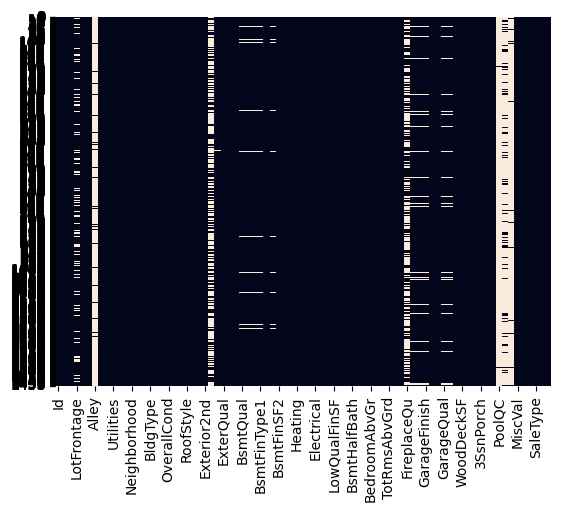

In [34]:
# Create a heatmap to visualize the nulls in the features

sns.heatmap(Housing_Data_All_Master.isnull(),yticklabels=True,cbar=False)

In [36]:
Housing_Data_All_Master['MSZoning'].mode()[0]

'RL'

In [37]:
Housing_Data_All_Master_Copy = Housing_Data_All_Master.copy()

<Axes: >

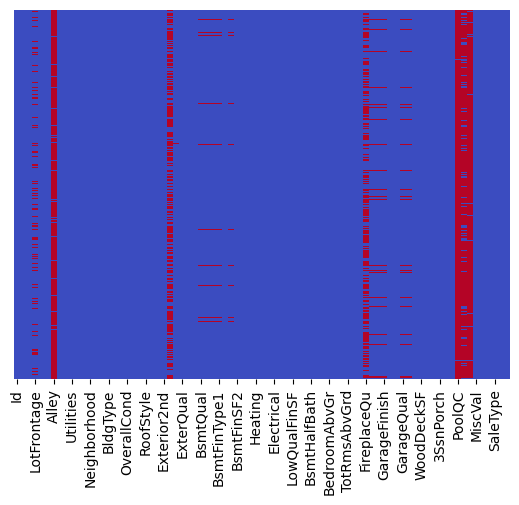

In [38]:
sns.heatmap(Housing_Data_All_Master_Copy.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

<Axes: >

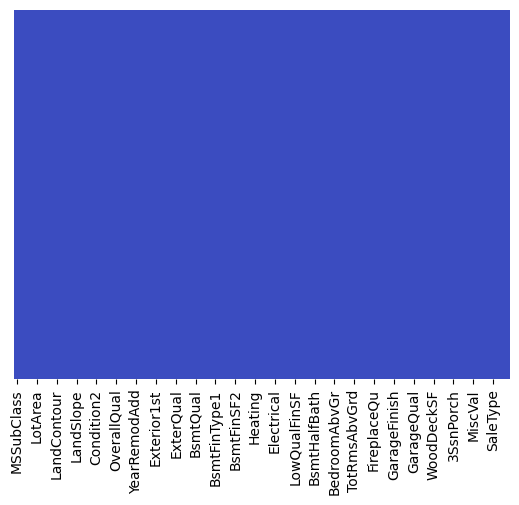

In [29]:
sns.heatmap(Housing_Data_All_Master_Copy.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

In [23]:
sum(Housing_Data_All_Master_Copy.BsmtFinType1.isnull())

37

In [25]:
sum(Housing_Data_All_Master_Copy.BsmtQual.isnull())

0

In [26]:
Housing_Data_All_Master_Copy['BsmtFinType1'] = Housing_Data_All_Master_Copy['BsmtFinType1'].fillna(Housing_Data_All_Master_Copy['BsmtFinType1'].mode()[0])

In [28]:
Housing_Data_All_Master_Copy.dropna(inplace=True)

In [30]:
Housing_Data_All_Master_Copy.shape

(1412, 75)

In [41]:
Housing_Data_All_Master_Copy['GarageYrBlt'].mean()[0]

IndexError: invalid index to scalar variable.

<Axes: >

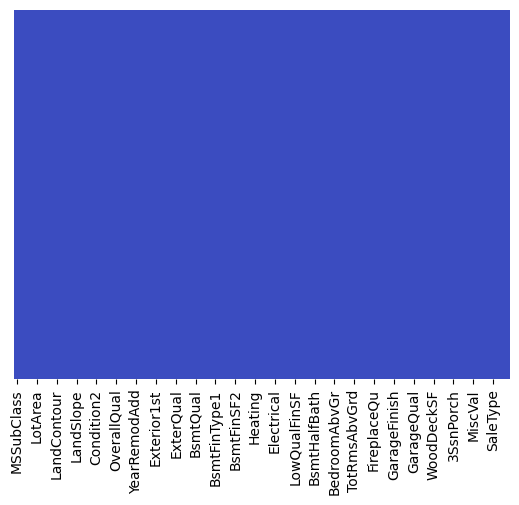

In [48]:
sns.heatmap(Housing_Data_All_Master_Copy.isnull(),yticklabels=False,cbar=False,cmap='coolwarm')

In [44]:
Housing_Data_All_Master_Copy['LotFrontage'] = Housing_Data_All_Master_Copy['LotFrontage'].fillna(Housing_Data_All_Master_Copy['LotFrontage'].mean())
Housing_Data_All_Master_Copy['GarageYrBlt'] = Housing_Data_All_Master_Copy['GarageYrBlt'].fillna(Housing_Data_All_Master_Copy['GarageYrBlt'].mean())

Housing_Data_All_Master_Copy['BsmtCond'] = Housing_Data_All_Master_Copy['BsmtCond'].fillna(Housing_Data_All_Master_Copy['BsmtCond'].mode()[0])
Housing_Data_All_Master_Copy['BsmtQual'] = Housing_Data_All_Master_Copy['BsmtQual'].fillna(Housing_Data_All_Master_Copy['BsmtQual'].mode()[0])
Housing_Data_All_Master_Copy['FireplaceQu'] = Housing_Data_All_Master_Copy['FireplaceQu'].fillna(Housing_Data_All_Master_Copy['FireplaceQu'].mode()[0])
Housing_Data_All_Master_Copy['GarageType'] = Housing_Data_All_Master_Copy['GarageType'].fillna(Housing_Data_All_Master_Copy['GarageType'].mode()[0])
Housing_Data_All_Master_Copy['GarageFinish'] = Housing_Data_All_Master_Copy['GarageFinish'].fillna(Housing_Data_All_Master_Copy['GarageFinish'].mode()[0])
Housing_Data_All_Master_Copy['GarageQual'] = Housing_Data_All_Master_Copy['GarageQual'].fillna(Housing_Data_All_Master_Copy['GarageQual'].mode()[0])
Housing_Data_All_Master_Copy['GarageCond'] = Housing_Data_All_Master_Copy['GarageCond'].fillna(Housing_Data_All_Master_Copy['GarageCond'].mode()[0])


In [47]:
Housing_Data_All_Master_Copy.dropna(inplace=True)

Housing_Data_All_Master_Copy.drop(['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'],axis=1,inplace = True)
Housing_Data_All_Master_Copy.drop(['Id'],axis=1,inplace = True)

KeyError: "['Alley', 'MasVnrType', 'PoolQC', 'Fence', 'MiscFeature'] not found in axis"

In [4]:
import numpy as np
Outlier_Values = np.sort(Outlier_Values)

In [5]:
Outlier_Values

array([  49,  186,  198,  250,  298,  314,  336,  441,  496,  524,  598,
        636,  636,  707,  739,  810,  935,  955,  955, 1062, 1299])